In [1]:
from IPython.display import display
import sympy as sp

from src.charts import fork
from src.charts import comparison
from src.charts import trail
from src.charts import caster
from src.charts import stability
from src.charts import wobble

# Motorcycle Stability Analysis. Tank Slapper Phenomena


### Contents

1. [Introduction](#1.-Introduction)
2. [Rake & Trail](#2.-Rake-&-Trail.)
    - 2.1 Motorcycle categorization
    - 2.2 Motorcycle fork and stability
3. [Active Forces on the Steering Assembly](#3.-Active-Forces-on-the-Steering-Assembly)
    - 3.1 The Caster Effect (Self-Centering Dynamics)
    - 3.2 Gyroscopic Precession
4. [The Tank Slapper (Death Wobble)](#4.-The-Tank-Slapper-(Death-Wobble))
    - 4.1 Modeling the tank Slapper
    - 4.2 Wobble Simulation
5. [Preventing the Tank Slapper](#5.-Preventing-the-Tank-Slapper)
    - 5.1 Steering Dampers
    - 5.2 Speed Awareness
    - 5.3 Rider Positioning and Input
    - 5.4 Obey Street Vehicle Laws
6. [Summary](#6.-Summary) 
7. [References](#6.-References)

## 1. Introduction

<div>
<img src="assets/10938-675-SR-R-2025-1000px.webp" width="300" style="float: left; margin-right: 15px;">
<p style="margin-left: 20px">Motorcycles are among the most dynamically complex vehicles on the road [8]. Unlike a car, which distributes its stability across four contact patches, a motorcycle balances on just two - relying entirely on the physics of its geometry, gyroscopic forces, and rider input.

This delicate balance is what makes them thrilling to ride, but it also makes them vulnerable to a terrifying phenomenon known as a **Tank Slapper** - a violent, high-frequency oscillation of the handlebars that can occur at speed with little to no warning.

To grasp a better understading of the phenomena, we will, firstly, investigate the mathematical foundations behind motorcycle front-end stability. Starting from basic steering geometry (rake and trail), we build up through gyroscopic effects and the caster self-centering mechanism to arrive at a simplified model of the **wobble mode** - the oscillatory instability responsible for the tank slapper event.

Our goal is to answer three questions:

1. **What geometric and physical parameters govern front-end stability?**
2. **At what circumstances does the steering system become unstable?**
3. **How can this instability be prevented or mitigated?**

We approach these questions using symbolic mathematics and numerical visualization, demonstrating that the onset of a tank slapper is not random - it is a predictable consequence of the system's eigenvalues crossing into the unstable region of the complex plane.</p>
</div>

## 2. Rake & Trail.

### 2.1 Motorcycle categorization.
The most primitive way in which a motorcycle can be seen is as a vechicle for transportation. Thougout the years this has evolved as with many other things around us. Nowadays, motorcycles use cases can have quite a broad variety - from the original use case, to an entusiast hobby and finally a complete competetive motor-sport.

This growth required specialization. As the market expanded, a single design could no longer satisfy the diverging needs of a global audience. This led to the birth of distinct categories, each engineered to excel in a specific environment or use case.

**The Categorization:**

- **Supersport:** Derived directly from the competitive motorsport sector, these machines are engineered for closed-circuit track performance. Design priorities center on aerodynamic efficiency and high-RPM power delivery.

- **Cruisers:** Designed for the enthusiast who prioritizes long-distance touring and aesthetic heritage over raw performance. 

- **Naked/Street:** Representing a modern refinement of the original utilitarian use-case, these vehicles serve as a versatile hybrid. By omitting the aerodynamic fairings of a sport-oriented machine, manufacturers provide a platform that maintains high performance while offering the upright ergonomic profile necessary for urban commuting and daily navigation.

- **Adventure (ADV):** These motorcycles serve as the bridge between standard road transportation and extreme exploration. They are characterized by long-travel suspension systems, increased ground clearance, and reinforced frames designed to maintain structural integrity across unpaved and technical terrain.

Later on in the study we will use this categorization for comparisons where applicable.



### 2.2 Motorcycle fork and stability.

The diversification of motorcycle types is fundamentally driven by the manipulation of steering geometry—specifically rake (the angle of the steering head from the vertical) and trail (the horizontal distance between the steering axis's ground contact point and the tire's actual contact patch). These factors, combined with fork architecture, define the vehicle’s feel and make different morocycles types appropriate for different use cases.

<div>
<img src="assets/ducati-supersport-S-2017-8.jpg" width="300" style="float: left; margin-right: 15px;">
<p style="margin-left: 20px"> Consider the motorcycle displayed on fig.1 [2]. This is a prime example for a SuperSport motorcycle. It features steep rake angle (typically $ 23\degree $ to $ 25\degree $) and short trail measurements (approx. 90–100 mm) [1]. This reduces the "lever arm" effect of the front wheel, lowering steering effort, increasing responsiveness and better control while leaning the bike in corners.</p>
</div>


fig.1 - Ducati supersport

<div>
<img src="assets/DSC09753.webp" width="300" style="float: right; margin-left: 15px;">
<p> Optimized for linear stability and long-distance comfort, Cruisers (fig.2) [3] utilize geometry that resists external disturbances. These vehicles employ relaxed rake angles ($ 30 \degree$ to $40\degree$ or more) and significantly longer trail measurements (often exceeding 120 mm) [1]. The increased trail creates a powerful self-centering force, providing a "heavy" but extremely stable feel at highway speeds.
</p>
</div>


<div style="float: right;">
    <p>fig.3 - Indian Cruiser</p>
</div>

If we compate the forks of the bikes, from fig.1 and fig.2 side by side, the difference would look like diagram 1:

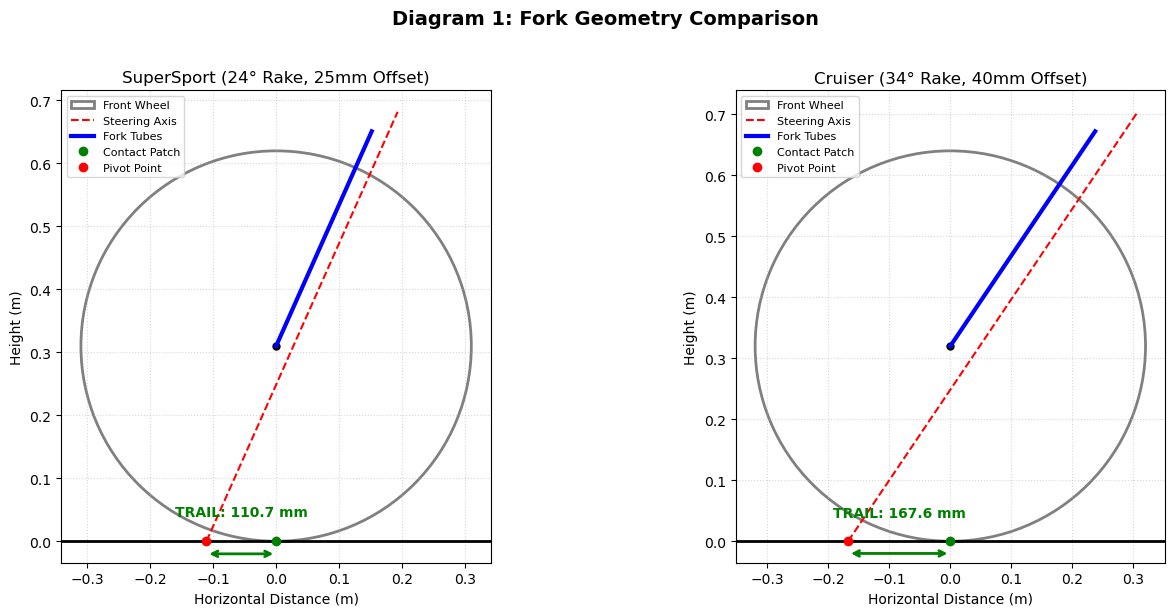

In [2]:
comparison.plot_fork_comparison([
    {'rake_deg': 24, 'offset_mm': 25, 'wheel_radius_mm': 310, 'title': 'SuperSport (24° Rake, 25mm Offset)'},
    {'rake_deg': 34, 'offset_mm': 40, 'wheel_radius_mm': 320, 'title': 'Cruiser (34° Rake, 40mm Offset)'},
], suptitle="Diagram 1: Fork Geometry Comparison")

If we try to solve for $t$ (trail) we can use the following formula, described by Vittore Cossalter
in *Motorcycle Dynamics* [1], where:

| Parameter | Description |
|---|---|
| **Rake angle** ($\lambda$) | The angle between the steering axis and the vertical. |
| **Fork offset** ($d$) | The perpendicular distance from the steering axis to the front axle (also called *triple-clamp offset*). |
| **Wheel radius** ($R$) | The radius of the front wheel including the tyre. |
| **Trail** ($t$) | The horizontal distance on the ground between the steering axis intersection and the tyre contact patch. |

$$
t = \frac{R \sin(\lambda) - d}{\cos(\lambda)}
$$

Trail is important, but it is not the only factor for death wobbles to occur. In the following sections we will take a look at a few more important details before drawing our summary. In the upcoming sections we will also use the term `mechanical trail` to describe trail. 

## 3. Active Forces on the Steering Assembly

### 3.1 The Caster Effect (Self-Centering Dynamics)

Everyone has experienced the caster effect without knowing it. Push a shopping cart forward and let go - the front wheels swing into alignment with the direction of travel. Motorcycles rely on exactly the same principle.

The caster effect is the tendency of a trailing wheel to align itself with the direction of motion. On a motorcycle, this self-centering behavior comes directly from **mechanical trail** - the distance we defined in Section 2. 

Now, if we imagine the wobble - because the tire's contact patch sits *behind* the point where the steering axis meets the ground, any lateral force at the contact patch creates a **restoring torque** around the steering axis [1]:

$$
T_{restore} = F_{lateral} \times t
$$

where $F_{lateral}$ is the side force acting on the tire and $t$ is the mechanical trail.

With generous trail (like the one on a cruiser bike), this restoring torque is strong and decisive - the wheel snaps back to center and the disturbance dies quickly. But as trail decreases, two things happen simultaneously:

1. **The restoring torque weakens.** A shorter lever arm means less corrective force for the same disturbance. The wheel still tries to self-center, but with less authority - giving the oscillation more time to develop.

2. **The overshoot grows.** When the wheel corrects, it carries momentum past the center line. With strong trail, the restoring torque catches the overshoot early and damps it. With weak trail, the wheel swings further past center before the geometry pulls it back - and each swing feeds energy into the next.



Inportant: **trail does not just set the magnitude of the restoring force - it sets the frequency and damping characteristics of the entire steering oscillation.** Lower trail raises the natural frequency of the wobble mode and reduces its damping ratio. At a certain forward speed, that damping ratio crosses zero, and the oscillation becomes self-sustaining.

But the caster effect is only half the story. The other force acting on the steering assembly is invisible until the wheels are spinning.

### 3.2 Gyroscopic Precession

<div>
<img src="assets/marc-lean.webp" width="300" style="float: left; margin-right: 15px;">
<p style="margin-left: 20px"> At fig. 3 we can see professional MotoGP rider Marc Marquez taking a turn at Silverstone Circuit on August 29, 2015 in Northampton, United Kingdom (Photo by Mirco Lazzari) [4]. Taking a look at the contact point for both tires raises one question - Why is the bike not falling to the ground and is still moving on? This is where Gyroscopic Precession comes into place.</p>
</div>

fig. 3


A spinning wheel does not behave like a stationary one. Once the front wheel is rotating at speed, it develops **angular momentum** - and angular momentum resists any attempt to change its orientation. This resistance is called the **gyroscopic effect**, and on a motorcycle it acts directly on the steering axis.

The angular momentum of the front wheel of a bike is [6]:

$$
L = I_w \omega_{spin} = I_w \frac{v}{R}
$$

where $I_w$ is the wheel's moment of inertia, $v$ is the forward speed, and $R$ is the wheel radius. The faster you go, the larger $L$ becomes.

When a rider (or a disturbance) applies a steering torque, the wheel does not simply turn in the direction of that torque. Instead, the gyroscopic effect produces a **precession torque** perpendicular to both the spin axis and the applied torque [6]:

$$
\tau_{gyro} = I_w  \frac{v}{R} \dot{\delta}
$$

where $\dot{\delta}$ is the rate of steering rotation (how fast the handlebars are turning).

Here is what this means for stability:

 - At **low speeds**, the gyroscopic torque is small - the angular momentum is weak, and the caster effect dominates. The front end behaves mostly like a shopping cart: geometric self-centering is all at work.

 - At **high speeds**, the gyroscopic torque becomes significant. It couples the steering motion to the roll motion of the motorcycle in a way that can either **stabilize** or **destabilize** the system depending on the phase relationship between the two.

The gyroscopic effect is not purely stabilizing. At certain speeds, the precession torque can fall *out of phase* with the caster restoring torque. When these two forces work against each other instead of together, the effective damping of the wobble mode drops- a nd if it drops below zero, the oscillation grows.

This interaction between the caster effect and gyroscopic precession is exactly what produces the tank slapper. Neither force alone causes the instability - it is their **coupling at a critical speed** that tips the system over the edge.

## 4. The Tank Slapper (Death Wobble)
We now have all the ingredients: mechanical trail creates a restoring torque via the caster effect, and the spinning front wheel adds a gyroscopic coupling that changes character with speed. It is time to try put them together.

A tank slapper is a violent, high-frequency oscillation of the handlebars where the front wheel swings rapidly from lock to lock. The name comes from the handlebars physically slapping the fuel tank at full deflection. In engineering terms, this is a wobble mode instability [5][9]: a self-sustaining oscillation of the steering assembly about the steering axis.

### 4.1 Modeling the tank slapper.

Let's try and put everything we know so far in a unified equation model. So far we know that -

- Smaller trails are more suseptable to tank slappers
- Higher velocity increases the chance to destabilize the system
- With the increase of velocity - the caster effect and the angular momentum grow (these can be a $f(v)$)
- We also need to take a look at the damping of the system (and how it stabilizes the system)
- We will also add the weigth of the front-end

We also know that in perfect condition, the system will remain in equilibrim. So a trigger is needed. The trigger is usually mundane - a bump, pothole, landing a wheelie slightly off-center, or a gust of crosswind at speed. What matters is not the size of the disturbance, but whether the system can damp it out or not. If the system cannot damp the disturbance one of the metrics is off and equilibrium is broken.

This leaves us with the following model:

$$
I_{steer} \, \ddot{\delta} \;+\; c_{eff}(v) \, \dot{\delta} \;+\; k_{eff}(v) \, \delta \;=\; 0
$$

where $\delta(t)$ is the steering angle deviation from straight ahead, and the coefficients are:

$$
k_{eff}(v) \approx C_1 \, v^{2} \, t_{trail}, \qquad C_1 = 10
$$

$$
c_{eff}(v) \approx c_{mech} - \sigma(v)
$$

$$
\sigma(v) \approx C_2 \, v^{2}, \qquad C_2 = 0.008
$$

> **Note:** In reality, $C_1$ and $C_2$ are not constants — they depend on tire properties, suspension geometry, load distribution, and other factors that change dynamically during riding. We treat them as fixed scaling coefficients here to keep the model analytically tractable while preserving the qualitative behavior of the system.

The stiffness $k_{eff}$ grows with the square of speed and is proportional to mechanical trail — more trail means a stronger restoring force (Caster Effect). The effective damping $c_{eff}$ is the competition between mechanical damping $c_{mech}$ (friction, steering damper) and the gyroscopic destabilization $\sigma(v)$ which also grows with $v^2$. When $\sigma(v)$ exceeds $c_{mech}$, the effective damping turns negative and the system becomes unstable.

The initial conditions represent the trigger event (a bump, gust, etc.):

$$
\delta(0) = \delta_0, \qquad \dot{\delta}(0) = 0
$$



### 4.2 Wobble Simulation
The charts below can help us understand the occurance of tank slappers in different settings. 

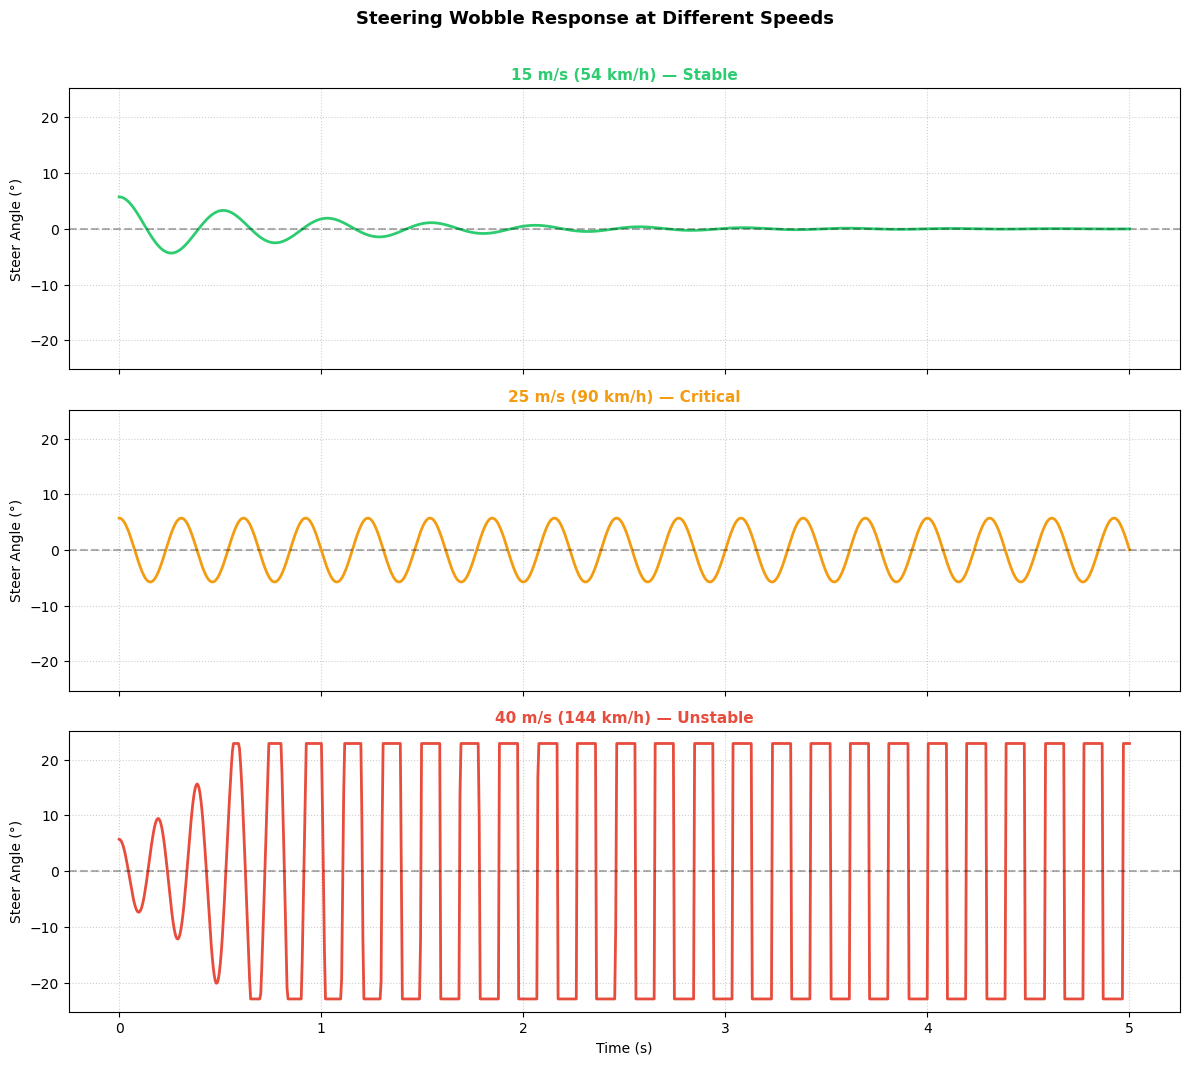

In [3]:
# === Shared simulation parameters ===
speeds_to_plot = [15, 25, 40]  # Forward speeds to simulate (m/s) — 54, 90, 144 km/h
t_span = (0, 5)                # Simulation window (seconds)
trigger_delta = 0.1            # Initial steering disturbance (radians)

# === Bike-specific geometry (uncomment one) ===

# --- Sportbike (no steering damper) ---
trail_val = 0.10        # Mechanical trail (m) — 100mm, aggressive geometry
c_mech = 5.0            # Damping (N·m·s/rad) — friction only, no damper
I_steer = 1.5           # Steering inertia (kg·m²) — light front end

# --- Cruiser (long trail, heavy steering, relaxed geometry) ---
# trail_val = 0.15         # Mechanical trail (m) — 150mm, long and stable
# c_mech = 7.0             # Damping (N·m·s/rad) — heavier friction from wide forks
# I_steer = 2.5            # Steering inertia (kg·m²) — heavy front wheel + fender + forks

# --- Adventure bike (ADV) — tall, long-travel suspension, mid-range geometry ---
# trail_val = 0.12        # Mechanical trail (m) — 120mm, balanced between sport and cruiser
# c_mech = 6.0            # Damping (N·m·s/rad) — moderate friction, long-travel forks absorb more
# I_steer = 2.0           # Steering inertia (kg·m²) — heavy 21" front wheel + crash bars + beak

# --- Sportbike with steering damper ---
# trail_val = 0.10        # Mechanical trail (m) — 100mm, same aggressive geometry
# c_mech = 9.0            # Damping (N·m·s/rad) — base friction (5.0) + damper (~4.0)
# I_steer = 1.5           # Steering inertia (kg·m²) — light front end

wobble.plot_wobble_comparison(trail_val, c_mech, I_steer, speeds_to_plot, t_span, trigger_delta)

## 5. Preventing the Tank Slapper

In practice, prevention can come down to 4 strategies: adding damping hardware, respecting the speed envelope, rider technique and obeying street laws.

### 5.1 Steering Dampers



<div>
<img src="assets/Steering-Damper-Close-Up.avif" width="300" style="float: right; margin-left: 15px;">
<p>The most direct engineering solution. A steering damper [10] is a small hydraulic or rotary device mounted between the frame and the steering stem that resists rapid rotation of the handlebars. In terms of our model, it increases the damping coefficient $c_{eff}$:

$$
c_{eff}^{damped}(v) = c_{eff}(v) + c_{damper}
$$
</p>
</div>

<div style="float: right;">fig. 4 - Öhlins steering damper [10]</div>

By adding a constant positive term to the effective damping, the steering damper shifts the entire eigenvalue curve downward - meaning the real part $\sigma$ stays negative to a much higher speed. The critical velocity $v_c$ is pushed well beyond the motorcycle's practical operating range.

Modern sportbikes, nearly all superbikes and some adventure bikes come equipped with adjustable steering dampers from the factory. The rider can tune the damping force - higher settings for track use at sustained high speed, lower settings for street riding where excessive damping would make low-speed maneuvering feel heavy and unresponsive.

It is worth noting that a steering damper does not eliminate the wobble mode - it simply ensures the system remains on the stable side across the bike's usable speed range.

### 5.2 Speed Awareness

The charts analysis in Section 4 showed that the wobble instability is fundamentally **speed-triggered**. Below the critical velocity, the system is self-correcting. Above it, every disturbance has the potential to escalate.

This has a practical implication that no amount of hardware can replace: knowing the limits of your machine. A motorcycle with 95mm of trail and no steering damper has a different critical speed than one with 120mm of trail and a factory damper. Riding beyond the stability envelope of your specific setup - whether through raw speed, worn suspension components, or incorrect tire pressure that alters the effective trail - is what creates the conditions for a tank slapper.

The critical speed is not fixed. It shifts with:
- **Tire wear** (changes contact patch geometry and pneumatic trail)
- **Suspension sag** (alters effective rake and trail)
- **Load distribution** (passenger, luggage shift weight balance)
- **Road surface** (wet roads reduce tire lateral force, changing the coupling dynamics)
- **Road surface Hazards** (potholes, bumps, speed bumps)

### 5.3 Rider Positioning and Input

This is counterintuitive, but one of the worst things a rider can do during a tank slapper is grip the handlebars tightly. A rigid grip couples the rider's upper body mass - arms, shoulders, torso - directly to the steering assembly. This effectively increases $I_{steer}$ and changes the resonant characteristics of the system in a way that can amplify the oscillation.

The recommended response:
- **Loosen the grip.** Allow the handlebars to oscillate freely. The steering damper and caster effect are designed to manage the wobble - the rider's arms fighting it only add energy.
- **Grip the tank with the knees.** This anchors the body to the chassis without coupling mass to the steering. The lower body stays planted while the handlebars do their thing.
- **Stay off the front brake.** Braking compresses the front forks, steepening the effective rake angle and *reducing* trail - exactly the opposite of what the system needs. It can push a manageable oscillation into full instability.
- **Gradual throttle.** Gently rolling on the throttle transfers weight to the rear, extending the front forks, increasing trail, and moving the system back toward stability.

The physics here is elegant: by changing body position and inputs, the rider is effectively tuning the parameters of the steering equation of motion in real time - increasing damping, increasing trail, and decoupling parasitic mass from the oscillating system.

### 5.4 Obey Street Vehicle Laws

Speed limits and road regulations exist, in part, because they keep vehicles within the stability envelope that their design was certified for. As our analysis showed, the wobble mode is fundamentally speed-triggered — there is a critical velocity beyond which the system cannot self-correct. Posted speed limits on public roads are set well below the thresholds where most street-legal motorcycles would enter the unstable regime.

Similarly, vehicle roadworthiness regulations — tire condition, suspension serviceability, steering head bearing play — directly govern the physical parameters in our model ($c_{mech}$, $t_{trail}$, $I_{steer}$). A motorcycle that passes inspection has these values within a safe operating range. Neglecting maintenance or modifying geometry outside of manufacturer specifications (e.g., lowering the front end, fitting incorrect tire sizes) shifts those parameters and can lower the critical speed into the everyday riding envelope.

## 6. Summary

The model presented in this notebook is a **simplified educational tool**, not a peer-reviewed scientific result. We used fixed scaling constants ($C_1$, $C_2$), treated velocity as a parameter rather than a dynamic variable, and ignored many real-world effects — tire deformation, frame flex, aerodynamic forces, rider biomechanics, and the nonlinear coupling between roll and steer that dominates actual motorcycle dynamics. A production-grade stability analysis (such as those in Cossalter [1] or Sharp [5]) involves far more degrees of freedom and experimentally validated parameters.

That said, the qualitative conclusions hold up:

1. **Stability is not guaranteed.** A motorcycle's steering system is conditionally stable — it works only within a bounded speed range determined by its geometry, damping, and inertia. Beyond that range, a small disturbance can escalate into a violent oscillation.

2. **Speed is the dominant risk factor.** Every configuration we tested — sportbike, cruiser, adventure bike — had a critical velocity above which the system became unstable. The margin between "self-correcting wobble" and "unrecoverable tank slapper" can be surprisingly narrow.

3. **Hardware helps, but physics cannot be cheated.** Steering dampers push the critical speed higher, and good maintenance keeps the model parameters in their intended range. But no amount of engineering eliminates the underlying bifurcation — it only moves it.

The practical takeaway is straightforward: motorcycles are governed by the same differential equations whether the rider understands them or not. Riding beyond the stability envelope — through excessive speed, deferred maintenance, or reckless modification — is not a matter of skill or luck. It is a predictable path toward a system failure that the rider may not be able to recover from.

---

## 7. References

| Ref | Source | Used in | Link |
|---|---|---|---|
| [1] | V. Cossalter, *Motorcycle Dynamics*, 2nd ed., 2006. | Trail formula, rake/trail values, caster restoring torque | [Google Books](https://books.google.bg/books/about/Motorcycle_Dynamics.html?id=rJTQxITnkbgC&redir_esc=y) |
| [2] | Ducati Motor Holding S.p.A., "Ducati SuperSport S," 2017. Ducati Media. | Fig.1 | [ducati.com](https://www.ducati.com/ww/en/bikes/supersport) |
| [3] | Custom Indian cruiser motorcycle | Fig.2 | — |
| [4] | M. Lazzari (photographer), "Marc Marquez, Silverstone Circuit, MotoGP," Aug 29, 2015. | Fig.3 | [Mirco Lazzari Site](https://www.mircolazzari.com/) |
| [5] | R. S. Sharp, "The Stability and Control of Motorcycles," *J. Mech. Eng. Sci.*, 1971. | Wobble mode, 7–10 Hz, eigenvalue model | [white paper](https://commons.princeton.edu/63-3-tiger-cub/wp-content/uploads/sites/263/2021/03/stability-of-motorcycles.pdf) |
| [6] | J. L. Meriam, L. G. Kraige, *Engineering Mechanics: Dynamics*, 8th ed., 2015. | Angular momentum, precession torque | [Google Books](https://books.google.bg/books/about/Engineering_Mechanics_Dynamics_8th_Editi.html?id=xrl2CwAAQBAJ&redir_esc=y) |
| [7] | S. H. Strogatz, *Nonlinear Dynamics and Chaos*, 2nd ed., 2015. | Hopf bifurcation theory | [White paper](https://www.biodyn.ro/course/literatura/Nonlinear_Dynamics_and_Chaos_2018_Steven_H._Strogatz.pdf) |
| [8] | CFMoto 675 SRR | Introduction image | [cfmoto.com](https://www.cfmoto.com/global/motorcycles/sportracing/675sr-r.html) |
| [9] | D. J. N. Limebeer, R. S. Sharp, "Bicycles, Motorcycles, and Models," *IEEE Control Syst. Mag.*, vol. 26, no. 5, pp. 34–61, 2006. | Wobble mode modeling, linearized steering EOM | [DOI](https://scispace.com/pdf/bicycles-motorcycles-and-models-pu5ta7rwyx.pdf) |
| [10] | Öhlins steering damper | fig.4 | [Ohlins site](https://www.ohlins.com/motorcycle-suspension)|